**Importing essential resourses**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

**Setting paths to the dataset**

In [2]:
data_train_path = "/content/drive/MyDrive/Deep learning IBM/Fruits_Vegetables/train"
data_test_path = "/content/drive/MyDrive/Deep learning IBM/Fruits_Vegetables/test"
data_val_path = "/content/drive/MyDrive/Deep learning IBM/Fruits_Vegetables/validation"

**Scaling the Images**

In [3]:
img_width = 180
img_height = 180

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Reading the data from the directory to the datasets**

In [5]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle = True,
    image_size = (img_height, img_width),
    batch_size = 32,
    validation_split = False
)

Found 3115 files belonging to 36 classes.


In [6]:
data_cat = data_train.class_names

In [7]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [8]:
data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    shuffle = False,
    image_size = (img_height, img_width),
    batch_size = 32,
    validation_split=False
)

Found 351 files belonging to 36 classes.


In [9]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    shuffle = False,
    image_size = (img_height, img_width),
    batch_size = 32,
    validation_split = False
)

Found 359 files belonging to 36 classes.


**Printing the Images form the Trainnig dataset**

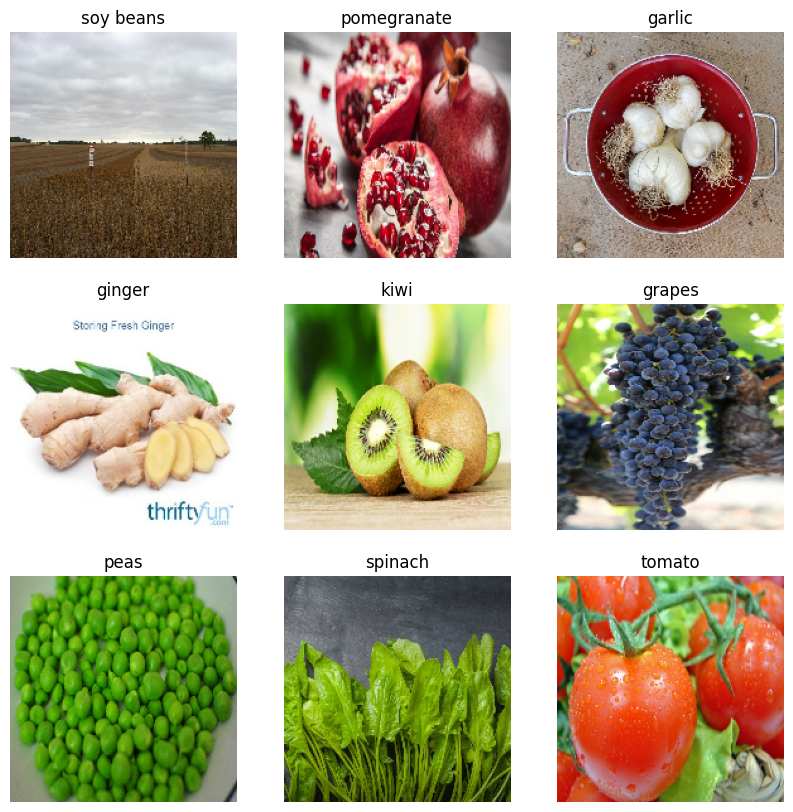

In [10]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(data_cat[labels[i]])
    plt.axis('off')


**Making Sequential Model**



*   Importing the sequential model the tensor's keras model




In [11]:
from tensorflow.keras.models import Sequential

In [12]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [13]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16,3,padding ='same', activation='relu' ),
    layers.MaxPool2D(),
    layers.Conv2D(32,3,padding ='same', activation='relu' ),
    layers.MaxPool2D(),
    layers.Conv2D(64,3,padding ='same', activation='relu' ),
    layers.MaxPool2D(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))


])

In [14]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
epochs_size = 25
history = model.fit(data_train,validation_data=data_val,epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 498s 5s/step - accuracy: 0.0989 - loss: 3.2429 - val_accuracy: 0.3020 - val_loss: 2.4503
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.2841 - loss: 2.4515 - val_accuracy: 0.4729 - val_loss: 1.8232
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.3766 - loss: 2.0998 - val_accuracy: 0.6182 - val_loss: 1.3548
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.4658 - loss: 1.7958 - val_accuracy: 0.6752 - val_loss: 1.2726
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.5554 - loss: 1.4980 - val_accuracy: 0.7977 - val_loss: 0.7739
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.6469 - loss: 1.2244 - val_accuracy: 0.8604 - val_loss: 0.5408
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.7136 - loss: 0.9729 - val_accuracy: 0.8746 - val_loss: 0.4865
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7743 - loss: 0.7482 - val_accuracy: 0.9202 - v

**Accuracy Graph**

Text(0.5, 1.0, 'Accuracy')

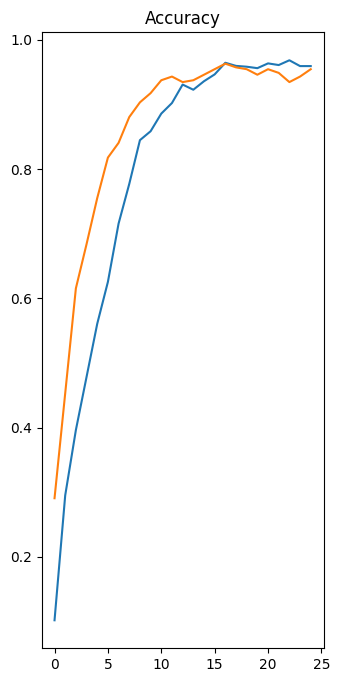

In [ ]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['accuracy'],label='Training Accuracy')
plt.plot(epochs_range,history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Accuracy')




**Loss graph**

Text(0.5, 1.0, 'Loss')

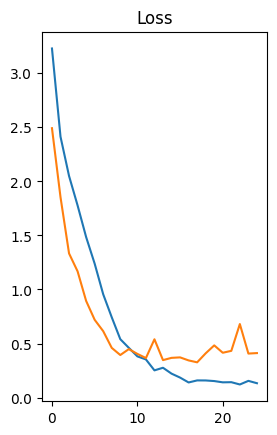

In [ ]:
plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label='Training loss')
plt.plot(epochs_range,history.history['val_loss'],label='Validation loss')
plt.title('Loss')

In [ ]:
image = '/content/drive/MyDrive/Deep learning IBM/Corn.jpg'
image = tf.keras.utils.load_img(image,target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat = tf.expand_dims(img_arr,0)

In [ ]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [ ]:
score = tf.nn.softmax(predict)

In [ ]:
print("Veg.fruit in image is {} with accuracy of {:0.2f}".format(data_cat[np.argmax(score)],np.max(score)*100))

Veg.fruit in image is sweetcorn with accuracy of 99.06


**WebApplication**

In [ ]:
model.save('/content/drive/MyDrive/Deep learning IBM/Fruits_Vegetables/Image_Classify.keras')